In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Load data from Phase 2
df = pd.read_csv("tsla_engineered_final.csv", index_col='Date', parse_dates=True)
print(f"Loaded dataset with shape: {df.shape}")
print(df.columns.tolist())

Loaded dataset with shape: (25815, 26)
['tweet_text', 'finbert_score', 'vader_score', 'textblob_score', 'Open', 'High', 'Low', 'Close', 'Volume', 'returns', 'log_returns', 'sma_10', 'sma_20', 'rsi', 'macd', 'bb_middle', 'bb_upper', 'bb_lower', 'momentum_10', 'volume_sma_10', 'fwd_return_1', 'fwd_return_3', 'fwd_return_7', 'fwd_return_14', 'sentiment_vol_3', 'sentiment_ma_5']


In [2]:
# Select features (you can adjust this list)
feature_columns = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'finbert_score', 'sentiment_vol_3', 'sentiment_ma_5',
    'sma_10', 'sma_20', 'rsi', 'macd', 'momentum_10', 'volume_sma_10'
]

target = 'fwd_return_1'   # Next day return (can change to price direction later)

X = df[feature_columns].values
y = df[target].values

print(f"Features shape: {X.shape}, Target shape: {y.shape}")

# Scale features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Create sequences
def create_sequences(data, target, seq_length=30):
    X_seq, y_seq = [], []
    for i in range(len(data) - seq_length):
        X_seq.append(data[i:i+seq_length])
        y_seq.append(target[i+seq_length])
    return np.array(X_seq), np.array(y_seq)

SEQ_LENGTH = 30
X_seq, y_seq = create_sequences(X_scaled, y, SEQ_LENGTH)

print(f"Sequence shape: {X_seq.shape}")

Features shape: (25815, 14), Target shape: (25815,)
Sequence shape: (25785, 30, 14)


In [3]:
train_size = int(len(X_seq) * 0.8)

X_train, X_test = X_seq[:train_size], X_seq[train_size:]
y_train, y_test = y_seq[:train_size], y_seq[train_size:]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (20628, 30, 14), Test: (5157, 30, 14)


In [4]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [5]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                           batch_first=True, dropout=dropout)
        self.fc1 = nn.Linear(hidden_size, 32)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(32, 1)
        
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.fc1(lstm_out[:, -1, :])   # take last time step
        out = self.dropout(out)
        out = self.fc2(out)
        return out

# Initialize model
input_size = X_seq.shape[2]
model = LSTMForecaster(input_size)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)

LSTMForecaster(
  (lstm): LSTM(14, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)


In [6]:
epochs = 50
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for X_batch, y_batch in tqdm(train_loader):
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    print(f"Epoch {epoch+1}/{epochs}, Loss: {train_loss/len(train_loader):.6f}")

# Save the trained model weights
import os
os.makedirs("models", exist_ok=True)
torch.save(model.state_dict(), "models/lstm_best.pth")
print(" Model weights successfully saved to models/lstm_best.pth")

100%|██████████| 645/645 [00:02<00:00, 267.96it/s]


Epoch 1/50, Loss: 0.001998


100%|██████████| 645/645 [00:01<00:00, 347.69it/s]


Epoch 2/50, Loss: 0.001851


100%|██████████| 645/645 [00:01<00:00, 340.70it/s]


...

Epoch 48/50, Loss: 0.000098


100%|██████████| 645/645 [00:01<00:00, 331.56it/s]


Epoch 49/50, Loss: 0.000095


100%|██████████| 645/645 [00:01<00:00, 337.24it/s]

Epoch 50/50, Loss: 0.000142
 Model weights successfully saved to models/lstm_best.pth


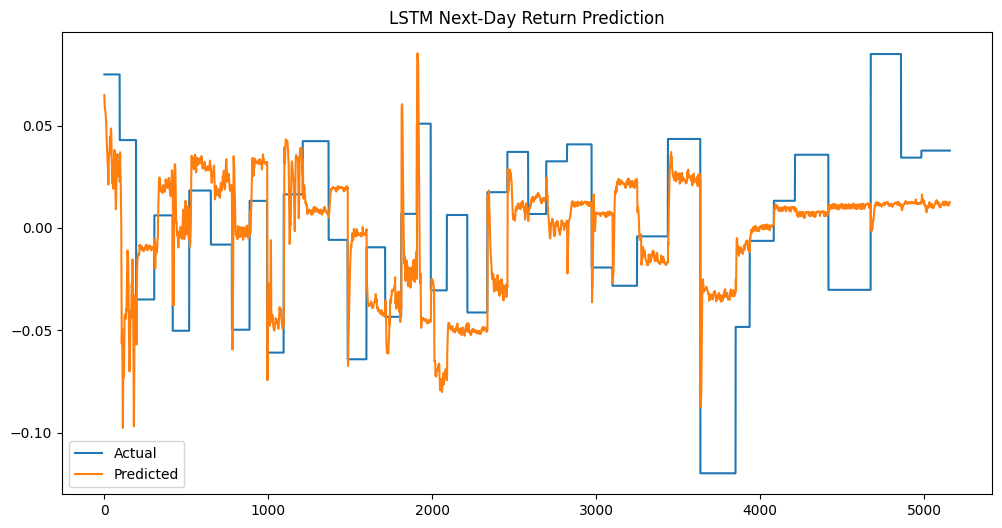

In [7]:
model.eval()
predictions = []
actuals = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        pred = model(X_batch).cpu().numpy()
        predictions.extend(pred.flatten())
        actuals.extend(y_batch.numpy().flatten())

# Plot results
plt.figure(figsize=(12,6))
plt.plot(actuals, label='Actual')
plt.plot(predictions, label='Predicted')
plt.title('LSTM Next-Day Return Prediction')
plt.legend()
plt.savefig("results/lstm_prediction.png")
plt.show()

In [8]:
import numpy as np

os.makedirs("data/processed", exist_ok=True)

# Save sequence arrays to disk
np.save("data/processed/X_seq.npy", X_seq)
np.save("data/processed/X_train.npy", X_train)
np.save("data/processed/X_test.npy", X_test)
